In [13]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from utils.model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

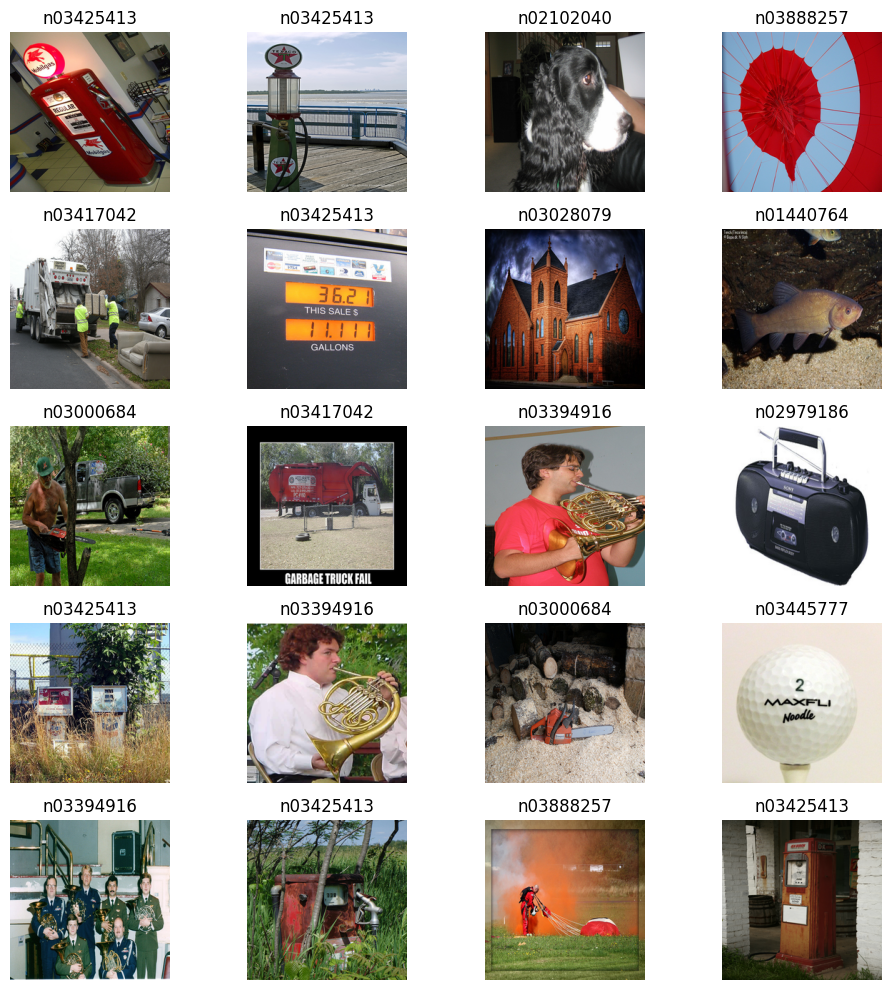

In [3]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [4]:
class ConvLayer():
    def __init__(self, num_filters, kernel_height, kernel_width, padding, stride):
        self.num_filters = num_filters
        self.kernel_height = kernel_height
        self.kernel_width = kernel_width
        self.padding = padding
        self.stride = stride
        self.filters = cp.random.random(size=(num_filters, 3, kernel_height, kernel_width))
    
    def flatten_filters(self):
        filter_columns = cp.prod(cp.array(self.filters.shape[-3:])).item()
        filters_matrix = cp.reshape(self.filters, newshape=(self.num_filters, filter_columns))
        return filters_matrix
    
    def im2col(self, x_batch):
        num_samples, num_channels, img_height, img_width = x_batch.shape

        x_padded = cp.pad(
            x_batch,
            ((0,0),(0,0),(self.padding,self.padding),(self.padding,self.padding))
        )

        img_height_padded = img_height + 2 * self.padding
        img_width_padded = img_width + 2 * self.padding

        output_height = (img_height_padded - self.kernel_height) // self.stride + 1
        output_width = (img_width_padded - self.kernel_width) // self.stride + 1

        i_offset = cp.repeat(cp.arange(self.kernel_height), self.kernel_width)
        i_offset = cp.tile(i_offset, num_channels)

        j_offset = cp.tile(cp.arange(self.kernel_width), self.kernel_height)
        j_offset = cp.tile(j_offset, num_channels)

        i_output = self.stride * cp.repeat(cp.arange(output_height), output_width)
        j_output = self.stride * cp.tile(cp.arange(output_width), output_height)

        i = i_offset.reshape(-1,1) + i_output.reshape(1,-1)
        j = j_offset.reshape(-1,1) + j_output.reshape(1,-1)

        k = cp.repeat(cp.arange(num_channels), self.kernel_height * self.kernel_width).reshape(-1,1)

        cols = x_padded[:, k, i, j]

        cols = cols.transpose(0,2,1).reshape(-1, num_channels * self.kernel_height * self.kernel_width)

        return cols, output_height, output_width
    
    def forward(self, x_batch):
        cols, out_h, out_w = self.im2col(x_batch)
        output = cols @ self.flatten_filters().T
        num_samples = x_batch.shape[0]
        output = output.reshape(num_samples, out_h, out_w, self.num_filters)
        output = output.transpose(0, 3, 1, 2)
        return output

In [10]:
conv_layer = ConvLayer(
    num_filters = 5,
    kernel_height = 3,
    kernel_width = 3,
    padding = 0,
    stride = 1
)

In [11]:
def forward(x_batch):
    return conv_layer.forward(x_batch)

In [12]:
for epoch in range(10):
    output = forward(x_train[:200])
    print(output.shape)

(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)
(200, 5, 222, 222)


In [ ]:
layer_definitions = [
    {"type": "ReLU", "input_size": 300, "num_neurons": 300},
    {"type": "ReLU", "input_size": 300, "num_neurons": 200},
    {"type": "ReLU", "input_size": 200, "num_neurons": 100},
    {"type": "ReLU", "input_size": 100, "num_neurons": 50},
    {"Sigmoid": "ReLU", "input_size": 20, "num_neurons": 1}
]

network = Network(layer_definitions=layer_definitions)

In [ ]:
network.describe()